In [67]:
# 1. Імпорти та завантаження датасету

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

df = pd.read_csv("global_tech_startups_2026.csv")

df.head()

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.8,23,0,23,Tier 3 (Angel/Seed),High,Independent
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
2,F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.1,59,0,59,Tier 2 (Mid-size VC),High,Independent
3,2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.7,76,0,76,Tier 3 (Angel/Seed),Medium,Independent
4,C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.0,59,28,31,Tier 2 (Mid-size VC),Medium,Closed


In [68]:
#відтворення даних з другого дз
numeric_df = df.select_dtypes(include=[np.number])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Видаляємо викиди
df_no_outliers = df[
    ~(
        (numeric_df < (Q1 - 1.5 * IQR)) |
        (numeric_df > (Q3 + 1.5 * IQR))
    ).any(axis=1)
].copy()

In [69]:
#Відтворення кластеризації KMeans із ДЗ №2

numeric_df = df_no_outliers.select_dtypes(include=[np.number])
scaler_kmeans = StandardScaler()

X_scaled = scaler_kmeans.fit_transform(numeric_df)

optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42
)
labels = kmeans.fit_predict(X_scaled)

df_no_outliers["cluster_kmeans"] = labels
df_no_outliers["cluster_kmeans"].value_counts()

cluster_kmeans
0    12259
2     4644
1     1826
Name: count, dtype: int64

In [70]:
# 4. Вибір двох кластерів з найбільшою кількістю елементів

largest_clusters = (
    df_no_outliers["cluster_kmeans"]
    .value_counts()
    .nlargest(2)
    .index
)

print("Два найбільші кластери:", list(largest_clusters))

df2 = df_no_outliers[
    df_no_outliers["cluster_kmeans"].isin(largest_clusters)
].copy()

print(df2["cluster_kmeans"].value_counts())

Два найбільші кластери: [0, 2]
cluster_kmeans
0    12259
2     4644
Name: count, dtype: int64


In [71]:
# Перетворення номерів кластерів у класи 0 і 1

df2["Class"] = df2["cluster_kmeans"].map({
    largest_clusters[0]: 0,
    largest_clusters[1]: 1
})

df2[["cluster_kmeans", "Class"]].head()

,cluster_kmeans,Class
0,0,0
2,0,0
3,2,1
4,0,0
6,0,0


In [72]:
# 5. Підготовка даних для класифікації методом опорних векторів

X = df2[
    [
        "Total_Funding_USD_Millions",
        "Valuation_USD_Millions"
    ]
]

y = df2["Class"]

print(X.head())
print()
print(y.head())

   Total_Funding_USD_Millions  Valuation_USD_Millions
0                        1.64                   17.81
2                       10.08                   43.37
3                       32.28                  257.62
4                       13.41                   76.73
6                        6.55                   72.71

0    0
2    0
3    1
4    0
6    0
Name: Class, dtype: int64


In [73]:
# 6. Поділ вибірки на навчальну та тестову

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Навчальна вибірка:", X_train.shape)
print("Тестова вибірка:", X_test.shape)

Навчальна вибірка: (13522, 2)
Тестова вибірка: (3381, 2)


In [74]:
# 7. Стандартизація ознак перед SVM

scaler_classification = StandardScaler()

X_train_scaled = scaler_classification.fit_transform(X_train)
X_test_scaled = scaler_classification.transform(X_test)

print(X_train_scaled[:5])

[[-0.52145753 -0.4935571 ]
 [-0.31461392 -0.55573149]
 [-0.71780907 -0.73268935]
 [ 0.19200303 -0.35619953]
 [-0.60089747 -0.54827056]]


In [75]:
# 8. Класифікація методом опорних векторів (SVM)

svm_model = SVC(
    kernel="linear",
    C=1
)

svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

In [76]:
# 9. Розрахунок точності SVM

svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print(f"Точність SVM: {svm_accuracy * 100:.2f}%")

Точність SVM: 95.68%


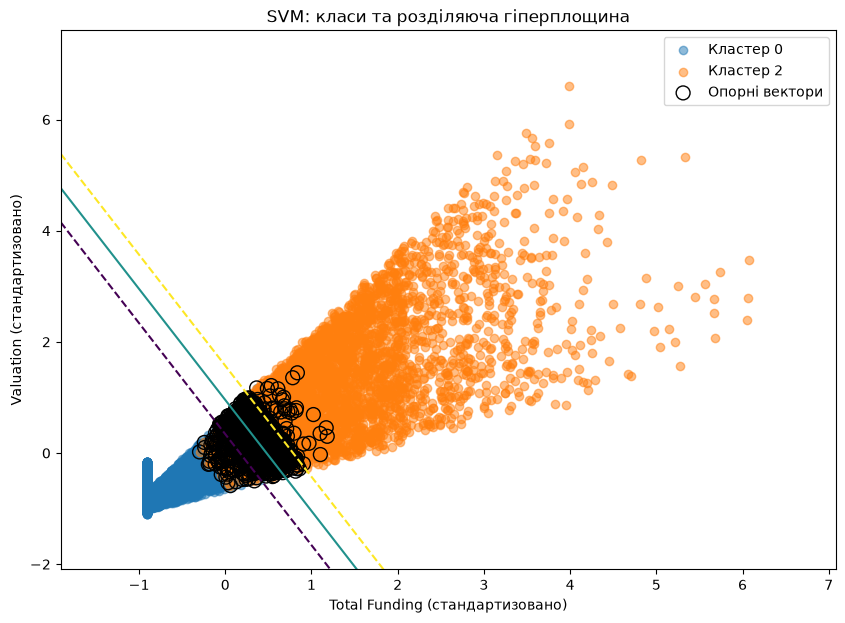

In [77]:
# 10. Побудова класів і розділяючої гіперплощини

# Межі графіка для першої ознаки
x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1

# Межі графіка для другої ознаки
y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1


# Створюю координатну сітку
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

# Для кожної точки сітки визначаємо її положення відносно розділяючої гіперплощини
Z = svm_model.decision_function(
    np.c_[xx.ravel(), yy.ravel()]
)

# Повертаю форму сітки
Z = Z.reshape(xx.shape)

# Створюю графік
plt.figure(figsize=(10, 7))

# Клас 0
plt.scatter(
    X_train_scaled[y_train.values == 0, 0],
    X_train_scaled[y_train.values == 0, 1],
    alpha=0.5,
    label=f"Кластер {largest_clusters[0]}"
)

# Клас 1
plt.scatter(
    X_train_scaled[y_train.values == 1, 0],
    X_train_scaled[y_train.values == 1, 1],
    alpha=0.5,
    label=f"Кластер {largest_clusters[1]}"
)


# -1 і 1 — межі margin а 0 — розділяюча гіперплощина
plt.contour(
    xx,
    yy,
    Z,
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"]
)

# Позначаю опорні вектори
plt.scatter(
    svm_model.support_vectors_[:, 0],
    svm_model.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    label="Опорні вектори"
)

plt.xlabel("Total Funding (стандартизовано)")
plt.ylabel("Valuation (стандартизовано)")
plt.title("SVM: класи та розділяюча гіперплощина")
plt.legend()
plt.show()

In [78]:
# 11. Пошук кількості сусідів K

# Перевіряю K від 1 до 30
k_values = range(1, 31)

# Сюди записуватиму точність кожного K
cv_accuracies = []

for k in k_values:

    #KNN для поточного K
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )

    # 3-fold cross-validation на навчальній вибірці
    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=3,
        scoring="accuracy"
    )

    # Середня точність для поточного K
    cv_accuracies.append(scores.mean())

In [79]:
# 12. Визначення мінімального K з accuracy >= 85%

selected_k = None

for k, accuracy in zip(k_values, cv_accuracies):

    if accuracy >= 0.85:
        selected_k = k
        break


if selected_k is not None:
    print(
        "Мінімальна кількість сусідів "
        "для точності не нижче 85%:",
        selected_k
    )
else:
    print(
        "Для K від 1 до 30 "
        "точності 85% не досягнуто."
    )

Мінімальна кількість сусідів для точності не нижче 85%: 1


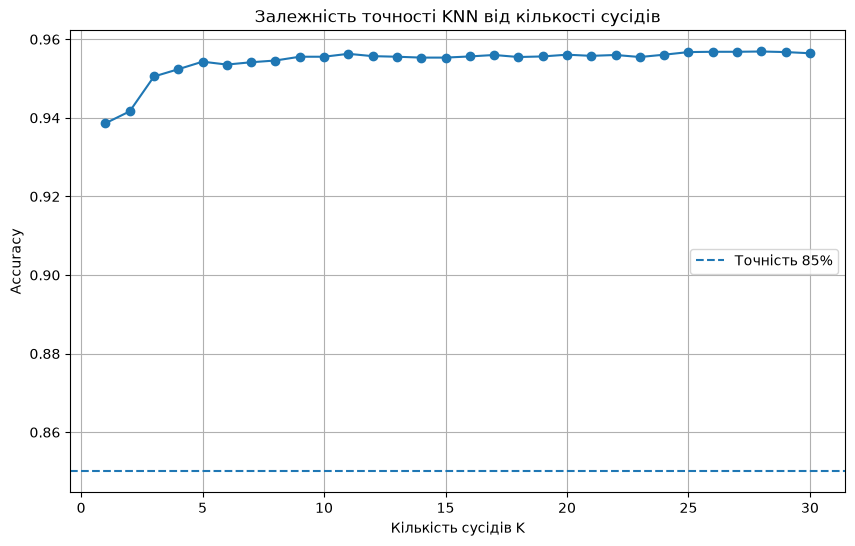

In [81]:
# 13. Графік точності для різних K

plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    cv_accuracies,
    marker="o"
)

plt.axhline(
    y=0.85,
    linestyle="--",
    label="Точність 85%"
)

plt.xlabel("Кількість сусідів K")
plt.ylabel("Accuracy")
plt.title("Залежність точності KNN від кількості сусідів")
plt.legend()
plt.grid()

plt.show()

In [82]:
# 14. Навчання фінальної моделі KNN

knn_model = KNeighborsClassifier(
    n_neighbors=selected_k,
    metric="euclidean"
)

knn_model.fit(
    X_train_scaled,
    y_train
)

y_pred_knn = knn_model.predict(
    X_test_scaled
)

In [83]:
# 15. Точність KNN на тестовій вибірці

knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print("Обране K:", selected_k)

print(
    f"Точність KNN на тестовій вибірці: "
    f"{knn_accuracy * 100:.2f}%"
)

Обране K: 1
Точність KNN на тестовій вибірці: 93.49%


In [84]:
# 16. Крос-валідація KNN на 3 блоках

cv_scores = cross_val_score(
    knn_model,
    X_train_scaled,
    y_train,
    cv=3,
    scoring="accuracy"
)

print("Точність на кожному блоці:")
print(cv_scores)
print(
    f"Середня точність 3-fold cross-validation: "
    f"{cv_scores.mean() * 100:.2f}%"
)

Точність на кожному блоці:
[0.94099379 0.9409807  0.93388063]
Середня точність 3-fold cross-validation: 93.86%
